# Notebook 1 - Data Loading, Cleaning & Exploration

**Project**: Replication of *"Autoencoder Market Models for Interest Rates"* (Sokol, 2022)

This notebook:
1. Loads Bloomberg OIS swap rate data for **GBP**, **EUR**, **USD**, **JPY**
2. Extracts the **7 key tenors**: 2Y, 3Y, 5Y, 10Y, 15Y, 20Y, 30Y
3. Handles missing data, aligns dates across currencies
4. Visualises historical swap curves
5. Saves a clean pickle file for downstream notebooks

## 0 - Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
Path("figs").mkdir(parents=True, exist_ok=True)
import pickle
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1 - Configuration

The paper encodes **7 swap rates** with maturities **2Y, 3Y, 5Y, 10Y, 15Y, 20Y, 30Y**.


In [15]:
DATA_PATH = Path("data/data.xlsx")

# Currency configuration: sheet name and ticker mapping
# Format in Excel: columns are "{TICKER} Curncy"

CURVE_CONFIG = {
    "GBP": {
        "sheet": "gbp ois results",
        "ticker_map": {
            2: "BPSWS2", 3: "BPSWS3", 5: "BPSWS5",
            10: "BPSWS10", 15: "BPSWS15", 20: "BPSWS20", 30: "BPSWS30"
        },
    },
    "EUR": {
        "sheet": "eur estr results",
        "ticker_map": {
            2: "EESWE2", 3: "EESWE3", 5: "EESWE5",
            10: "EESWE10", 15: "EESWE15", 20: "EESWE20", 30: "EESWE30"
        },
    },
    "USD": {
        "sheet": "usd sofr results",
        "ticker_map": {
            2: "USOSFR2", 3: "USOSFR3", 5: "USOSFR5",
            10: "USOSFR10", 15: "USOSFR15", 20: "USOSFR20", 30: "USOSFR30"
        },
    },
    "JPY": {
        "sheet": "jpy ois results",
        "ticker_map": {
            2: "JYSO2", 3: "JYSO3", 5: "JYSO5",
            10: "JYSO10", 15: "JYSO15", 20: "JYSO20", 30: "JYSO30"
        },
    },
}

# Target tenors 
TARGET_TENORS = [2, 3, 5, 10, 15, 20, 30]

print("Currencies:", list(CURVE_CONFIG.keys()))
print("Target tenors (years):", TARGET_TENORS)


Currencies: ['GBP', 'EUR', 'USD', 'JPY']
Target tenors (years): [2, 3, 5, 10, 15, 20, 30]


## 2 - Load and parse Excel data

The file format is clean:
- Column 0: `eod_date`
- Columns 1-8: `{TICKER} Curncy` with numeric values

In [16]:
def load_swap_curves(data_path: Path) -> dict[str, pd.DataFrame]:
    
    swap_data = {}
    
    for ccy, cfg in CURVE_CONFIG.items():
        sheet = cfg["sheet"]
        ticker_map = cfg["ticker_map"]
        
        # Read the sheet
        df = pd.read_excel(data_path, sheet_name=sheet)
        df.columns = [str(c).strip() for c in df.columns]
        
        df["eod_date"] = pd.to_datetime(df["eod_date"], dayfirst=True, errors="coerce")
        df = df.dropna(subset=["eod_date"]).sort_values("eod_date")
        
        
        # Extract tenor columns
        out = pd.DataFrame({"eod_date": df["eod_date"].values})
        
        for tenor, ticker in ticker_map.items():
            col_name = f"{ticker} Curncy"
            if col_name not in df.columns:
                raise KeyError(f"[{ccy}] Missing column: {col_name} in sheet {sheet}")
            out[tenor] = df[col_name].astype(float) /100.0
        
        # Set index and sort columns
        out = out.set_index("eod_date")
        out = out[sorted(out.columns)]
        
        swap_data[ccy] = out
        print(f" {ccy}: {len(out)} obs, {out.index.min().date()} → {out.index.max().date()}")
    
    return swap_data

In [17]:
swap_data = load_swap_curves(DATA_PATH)

 GBP: 753 obs, 2023-01-30 → 2026-01-09
 EUR: 757 obs, 2023-01-30 → 2026-01-12
 USD: 750 obs, 2023-01-30 → 2026-01-05
 JPY: 751 obs, 2023-01-30 → 2026-01-21


In [18]:
# Quick check
swap_data["GBP"].tail(3)

,2,3,5,10,15,20,30
eod_date,,,,,,,
2026-01-07,0.034847,0.035355,0.036633,0.040015,0.042636,0.044028,0.044625
2026-01-08,0.034844,0.035480,0.036935,0.040501,0.043161,0.044591,0.045216
2026-01-09,0.034903,0.035194,0.036597,0.040129,0.042801,0.044219,0.044841


## 3 - Data quality checks

In [19]:
for ccy, df in swap_data.items():
    n_obs = len(df)
    n_missing = df.isna().sum().sum()
    pct_missing = 100 * n_missing / df.size
    
    print(f"\n{ccy}:")
    print(f"  Observations: {n_obs}")
    print(f"  Date range: {df.index.min().date()} → {df.index.max().date()}")
    print(f"  Missing values: {n_missing} ({pct_missing:.2f}%)")
    
    if n_missing > 0:
        print(f"  Missing by tenor:")
        for col in df.columns:
            missing = df[col].isna().sum()
            if missing > 0:
                print(f"    {col}Y: {missing}")


GBP:
  Observations: 753
  Date range: 2023-01-30 → 2026-01-09
  Missing values: 0 (0.00%)

EUR:
  Observations: 757
  Date range: 2023-01-30 → 2026-01-12
  Missing values: 0 (0.00%)

USD:
  Observations: 750
  Date range: 2023-01-30 → 2026-01-05
  Missing values: 0 (0.00%)

JPY:
  Observations: 751
  Date range: 2023-01-30 → 2026-01-21
  Missing values: 0 (0.00%)


## 4 - Align dates across currencies

In [20]:
# Find common dates across ALL currencies
common_dates = None
for ccy, df in swap_data.items():
    idx = df.dropna(axis=0, how="any").index
    common_dates = idx if common_dates is None else common_dates.intersection(idx)

common_dates = common_dates.sort_values()
print(f"Common dates across {len(swap_data)} currencies: {len(common_dates)}")
print(f"Range: {common_dates.min().date()} → {common_dates.max().date()}")

# Create aligned DataFrames (identical date index)
swap_aligned = {ccy: df.loc[common_dates].copy() for ccy, df in swap_data.items()}

Common dates across 4 currencies: 712
Range: 2023-01-30 → 2026-01-05


## 5 - Build stacked multi-currency DataFrame

In [21]:
# Stack all currencies into single DataFrame for VAE training
frames = []
for ccy, df in swap_aligned.items():
    tmp = df.copy()
    tmp["currency"] = ccy
    frames.append(tmp)

df_multi = pd.concat(frames, axis=0).sort_index()
df_multi = df_multi.reset_index()
if "index" in df_multi.columns:
    df_multi = df_multi.rename(columns={"index": "eod_date"})
    
print(f"Multi-currency stacked shape: {df_multi.shape}")
print(f"\nCurrency distribution:")
print(df_multi["currency"].value_counts())
print(f"\nSample:")
df_multi.head()

Multi-currency stacked shape: (2848, 9)

Currency distribution:
currency
GBP    712
EUR    712
JPY    712
USD    712
Name: count, dtype: int64

Sample:


,eod_date,2,3,5,10,15,20,30,currency
0,2023-01-30,0.040745,0.038584,0.036176,0.033815,0.033405,0.032945,0.031835,GBP
1,2023-01-30,0.030730,0.028790,0.026830,0.026240,0.026500,0.025482,0.022740,EUR
2,2023-01-30,0.001812,0.002787,0.004490,0.008688,0.011437,0.013338,0.014000,JPY
3,2023-01-30,0.042630,0.038290,0.034487,0.032424,0.032412,0.032023,0.029954,USD
4,2023-01-31,0.001788,0.002713,0.004375,0.008525,0.011212,0.013025,0.013600,JPY


## 6 - Visualise historical swap curves

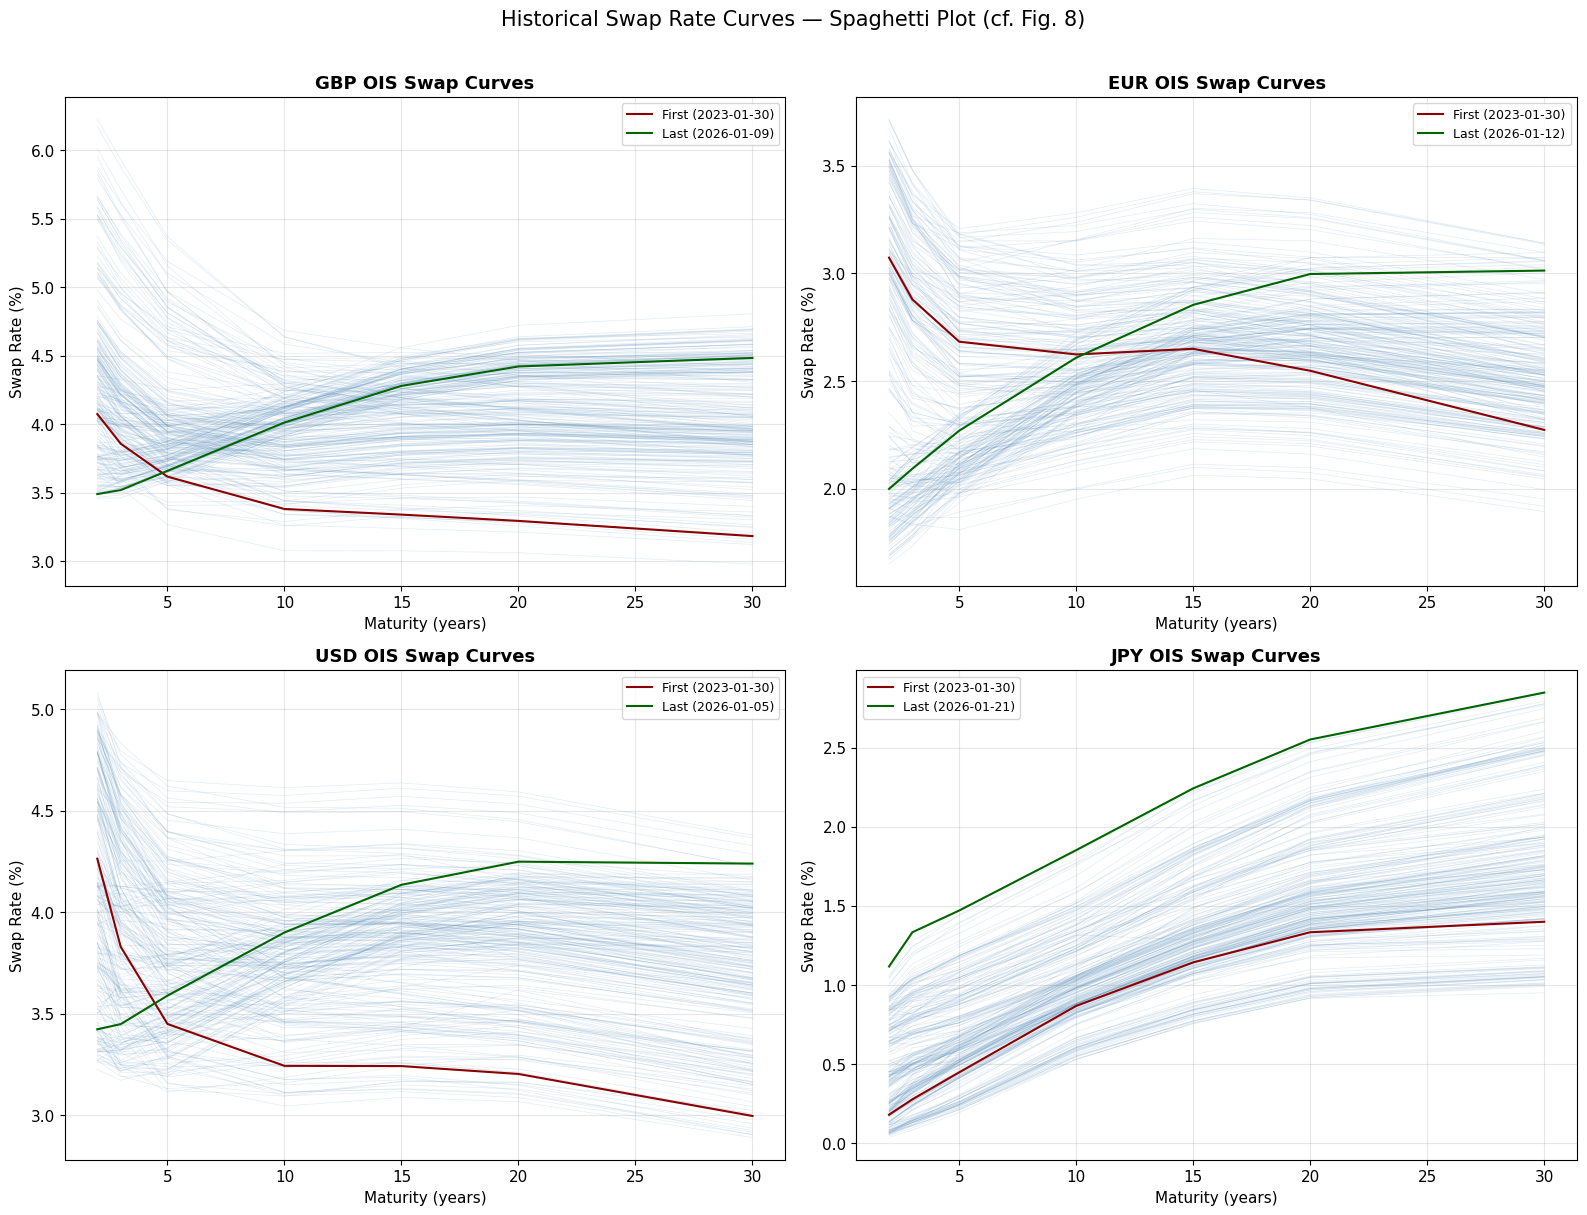

In [22]:
# Plot 1: Spaghetti plot (cf Fig. 8 in paper)
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=False)
axes = axes.flatten()

for ax, ccy in zip(axes, CURVE_CONFIG.keys()):
    df = swap_data[ccy]
    tenors = np.array(df.columns, dtype=float)
    
    for i in range(0, len(df), 3):
        ax.plot(tenors, 100 *df.iloc[i].values, alpha=0.15, linewidth=0.5, color="steelblue")
    
    # Highlight first and last curves
    ax.plot(tenors, 100 *df.iloc[0].values, color="darkred", linewidth=1.5, 
            label=f"First ({df.index[0].date()})")
    ax.plot(tenors, 100 *df.iloc[-1].values, color="darkgreen", linewidth=1.5,
            label=f"Last ({df.index[-1].date()})")
    
    ax.set_title(f"{ccy} OIS Swap Curves", fontsize=13, fontweight="bold")
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Swap Rate (%)")
    ax.legend(fontsize=9)

fig.suptitle("Historical Swap Rate Curves — Spaghetti Plot (cf. Fig. 8)", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("figs/fig_01_spaghetti.png", dpi=150, bbox_inches="tight")
plt.show()

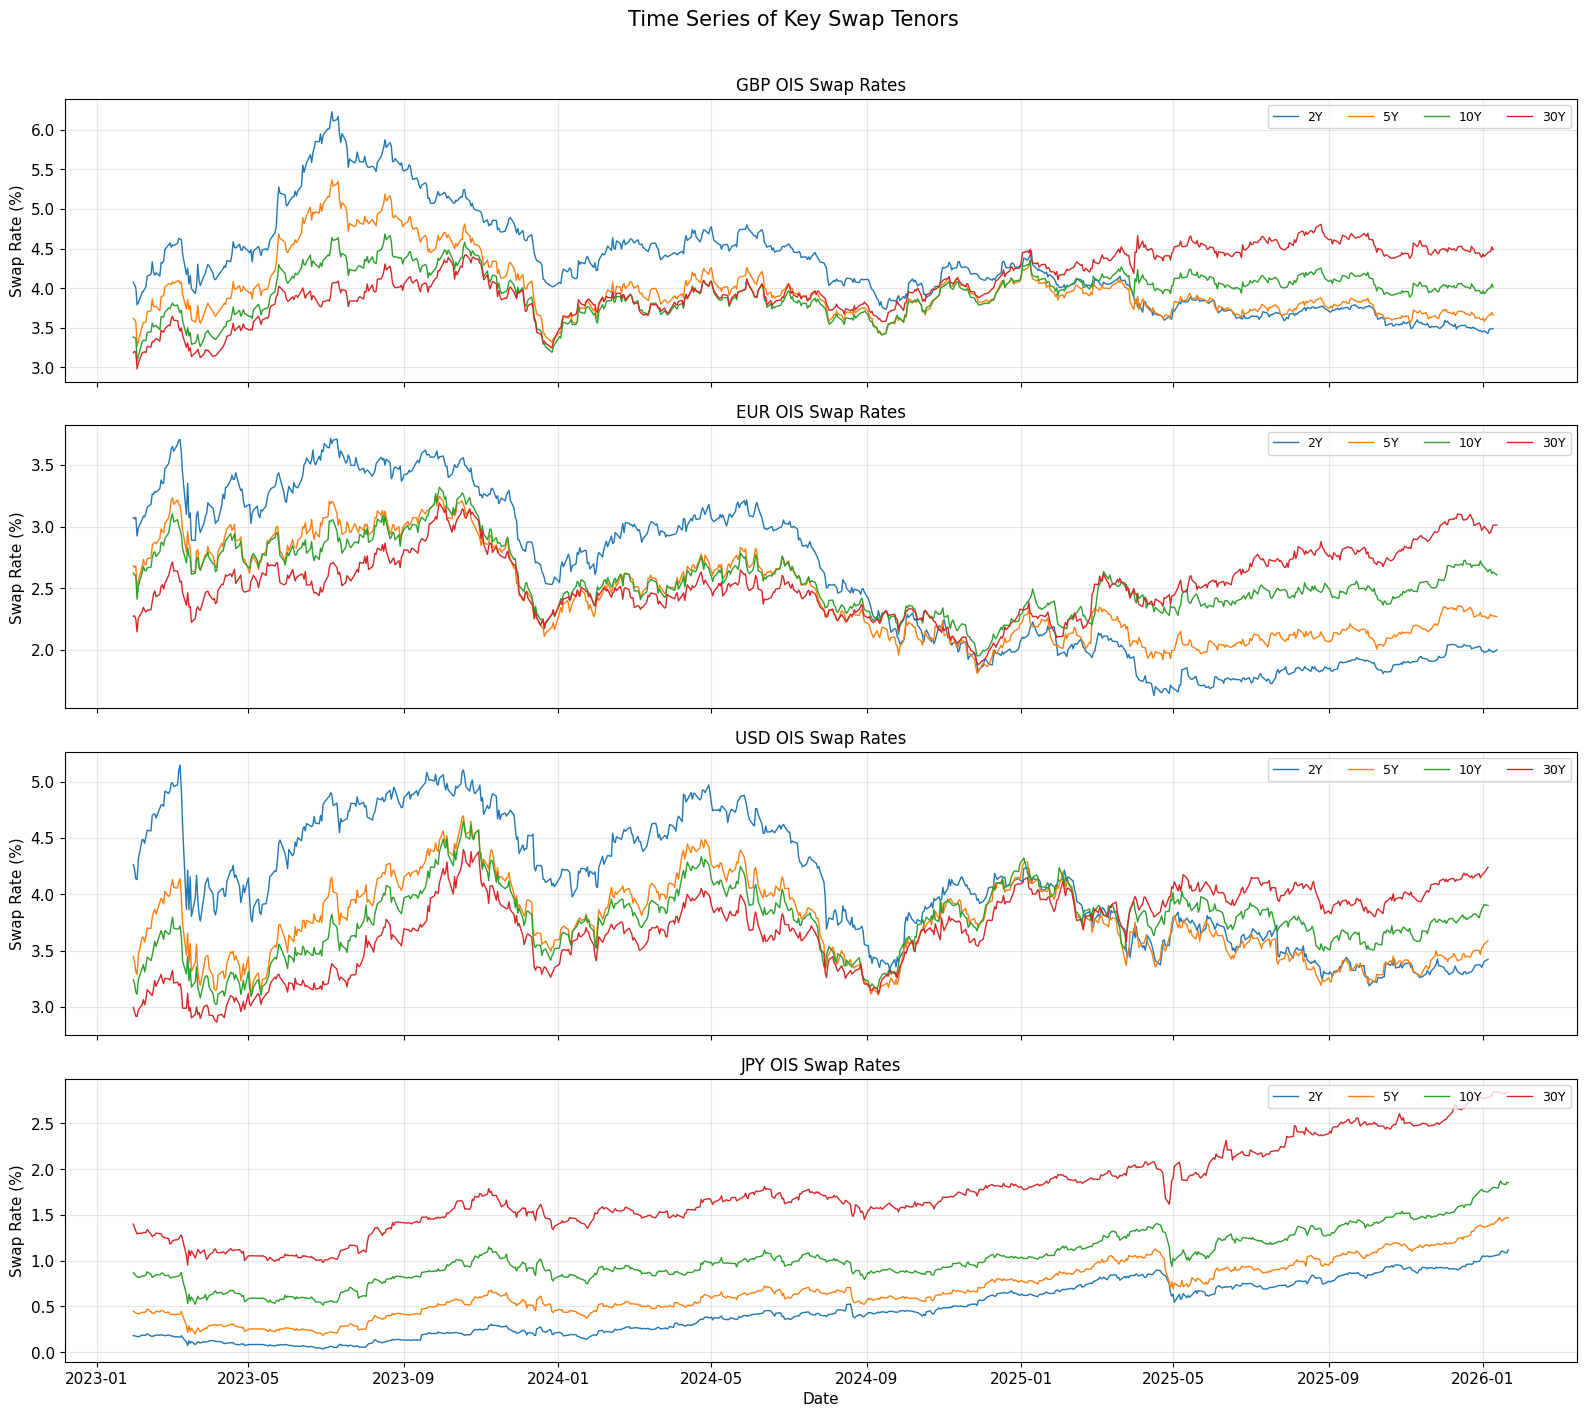

In [23]:
# Plot 2: Time series of selected tenors
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

colors = {2: "tab:blue", 5: "tab:orange", 10: "tab:green", 30: "tab:red"}

for ax, ccy in zip(axes, CURVE_CONFIG.keys()):
    df = swap_data[ccy]
    for tenor in [2, 5, 10, 30]:
        if tenor in df.columns:
            ax.plot(df.index, 100 * df[tenor], label=f"{tenor}Y", 
                   linewidth=1.0, color=colors[tenor])
    
    ax.set_ylabel("Swap Rate (%)")
    ax.set_title(f"{ccy} OIS Swap Rates", fontsize=12)
    ax.legend(loc="upper right", ncol=4, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xlabel("Date")
fig.suptitle("Time Series of Key Swap Tenors", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("figs/fig_02_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

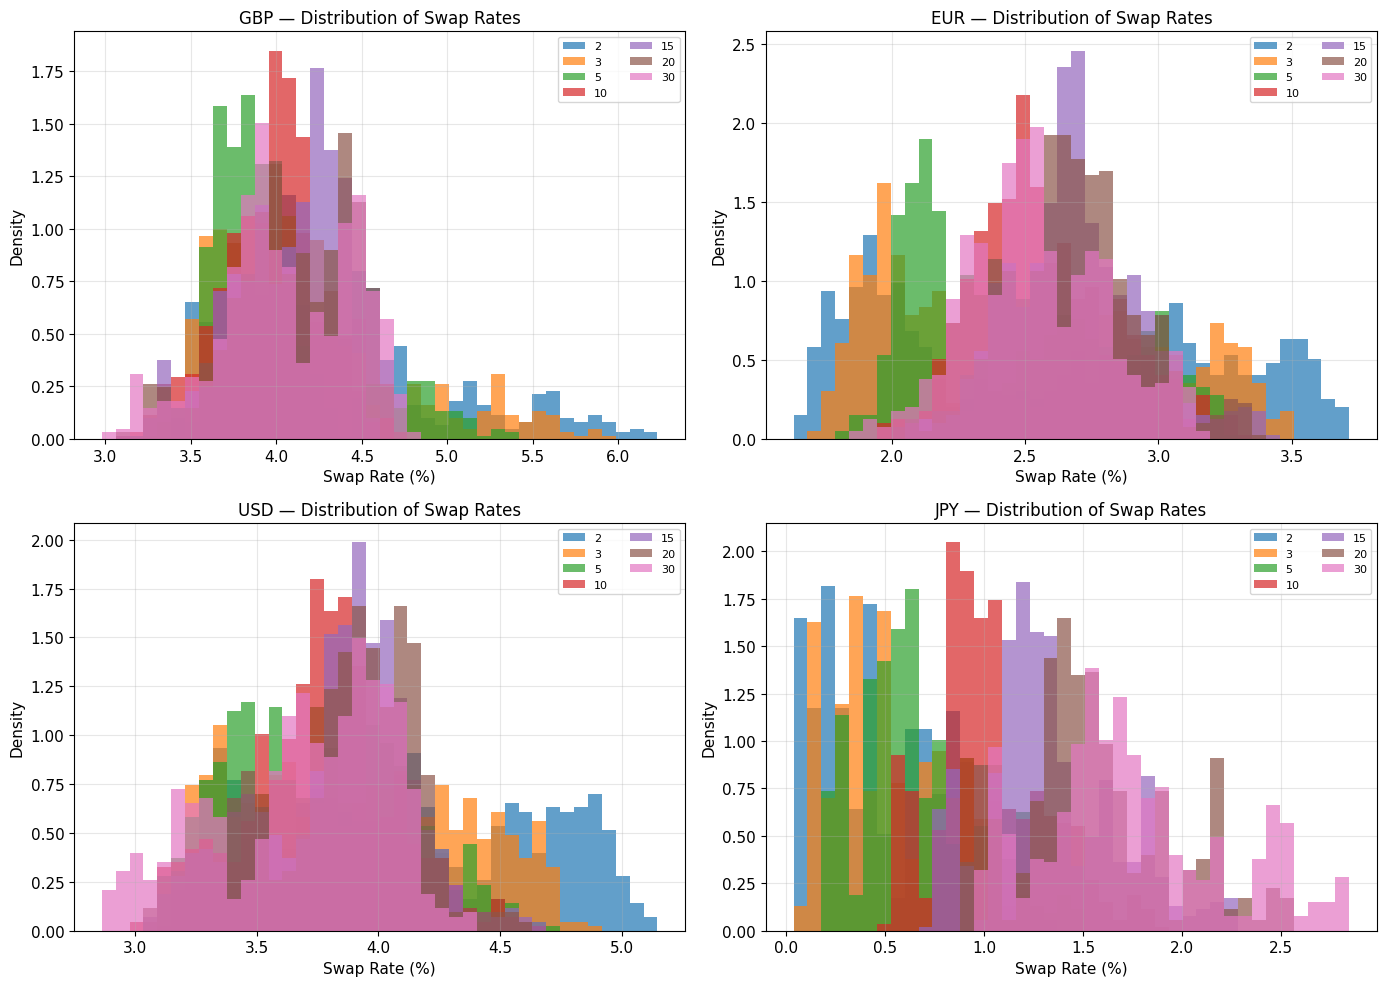

In [24]:
# Plot 3: Distribution of swap rates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, ccy in zip(axes, CURVE_CONFIG.keys()):
    df = swap_data[ccy]
    (100 * df).plot.hist(ax=ax, bins=40, alpha=0.7, legend=True, density=True)
    ax.set_title(f"{ccy} — Distribution of Swap Rates", fontsize=12)
    ax.set_xlabel("Swap Rate (%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("figs/fig_03_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 - Curve shape analysis (Level, Slope, Curvature)

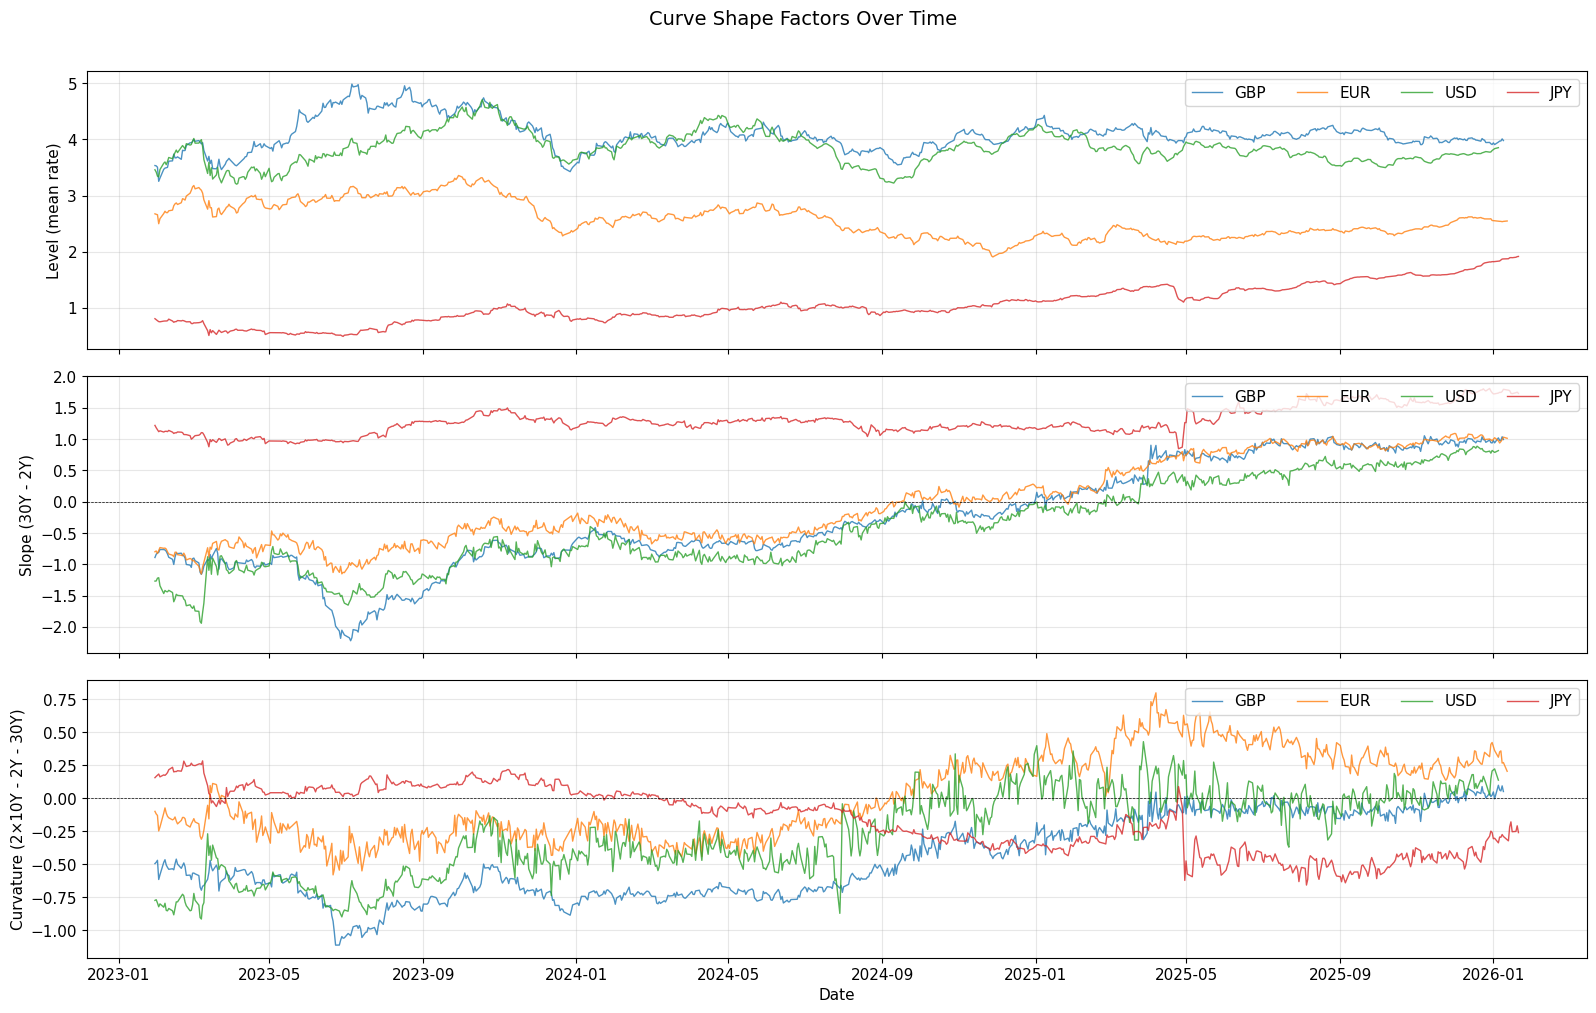

In [25]:
# Compute proxy factors for each currency
factor_analysis = {}

for ccy, df in swap_data.items():
    factors = pd.DataFrame(index=df.index)
    
    # Level: average across all tenors
    factors["level"] = 100 * df.mean(axis=1)
    
    # Slope: 30Y - 2Y spread
    factors["slope"] = 100 * (df[30] - df[2])
    
    # Curvature: 2×10Y - 2Y - 30Y (butterfly)
    factors["curvature"] = 100 * (2 * df[10] - df[2] - df[30])
    
    factor_analysis[ccy] = factors

# Plot factor time series
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
factor_names = ["level", "slope", "curvature"]
factor_labels = ["Level (mean rate)", "Slope (30Y - 2Y)", "Curvature (2×10Y - 2Y - 30Y)"]

for ax, fname, flabel in zip(axes, factor_names, factor_labels):
    for ccy in CURVE_CONFIG.keys():
        ax.plot(factor_analysis[ccy].index, factor_analysis[ccy][fname], 
               label=ccy, linewidth=1.0, alpha=0.8)
    ax.set_ylabel(flabel)
    ax.legend(loc="upper right", ncol=4)
    if fname != "level":
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

plt.xlabel("Date")
fig.suptitle("Curve Shape Factors Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figs/fig_04_factors.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 - Save cleaned data

In [26]:
# Prepare output dictionary
output = {
    "swap_data": swap_data,           # Per-currency, all available dates
    "swap_aligned": swap_aligned,     # Common dates only (for multi-ccy training)
    "df_multi": df_multi,             # Stacked multi-currency DataFrame
    "common_dates": common_dates,     # List of common dates
    "target_tenors": TARGET_TENORS,   # [2, 3, 5, 10, 15, 20, 30]
    "config": CURVE_CONFIG,           # Currency configuration
    "factor_analysis": factor_analysis,  # Level/Slope/Curvature proxies
}

# Save
save_path = "clean_swap_data.pkl"
with open(save_path, "wb") as f:
    pickle.dump(output, f)

print(f"Saved cleaned data to '{save_path}'")
print(f"\nDataset summary:")
for ccy in CURVE_CONFIG.keys():
    print(f"   {ccy}: {swap_data[ccy].shape}")
print(f"   Common aligned dates: {len(common_dates)}")
print(f"   Multi-currency rows: {len(df_multi)}")

Saved cleaned data to 'clean_swap_data.pkl'

Dataset summary:
   GBP: (753, 7)
   EUR: (757, 7)
   USD: (750, 7)
   JPY: (751, 7)
   Common aligned dates: 712
   Multi-currency rows: 2848
